<h1>Histogram and Intensity Transformations</h1>


<h2>Objectives</h2>


Pixel Transforms are operations you perform one pixel at a time. In this lab, you will start by creating histograms. Histograms display the intensity of the image and can be used to optimize image characteristics. You will then apply Intensity Transformations, making objects easier to see by improving image contrast and brightness. In the last portion of the lab, you will use thresholding to segment objects from images.


<ul>
    <li><a href='https://#PT'>Pixel Transforms  </a>
        <ul>
            <li>Histograms </li>
            <li>Intensity Transformations</li>
            <li>Thresholding and Simple Segmentation </li>   
</ul>


***


We will be using these imported functions in the lab


In [1]:
#import the necessary libraries
import matplotlib.pyplot as plt
import cv2
import numpy as np
import os

First, lets define a helper function to plot two images side-by-side. You will not need to understand this code at this moment, but this function will be used repeatedly in this tutorial to showcase the results.


In [2]:
def plot_image(image_1, image_2,title_1="Orignal", title_2="New Image"):
    plt.figure(figsize=(10,10))
    plt.subplot(1, 2, 1)
    plt.imshow(image_1,cmap="gray")
    plt.title(title_1)
    plt.subplot(1, 2, 2)
    plt.imshow(image_2,cmap="gray")
    plt.title(title_2)
    plt.show()

Lets define another helper function. The following one will plot two histograms side-by-side. Again, you do not need to understand the body of this function at this moment.


In [3]:
def plot_hist(old_image, new_image, title_old="Orignal", title_new="New Image"):
    intensity_values=np.array([x for x in range(256)])
    plt.subplot(1, 2, 1)
    plt.bar(intensity_values, cv2.calcHist([old_image],[0],None,[256],[0,256])[:,0],width = 5)
    plt.title(title_old)
    plt.xlabel('intensity')
    plt.subplot(1, 2, 2)
    plt.bar(intensity_values, cv2.calcHist([new_image],[0],None,[256],[0,256])[:,0],width = 5)
    plt.title(title_new)
    plt.xlabel('intensity')
    plt.show()

# Histograms


A histogram counts the number of occurrences of the intensity values of pixels, and it's a useful tool for understanding and manipulating images. We use <code>cv.calcHist()</code> to generate the histogram. Here are the parameter values:

<p>
    <code>cv2.calcHist(CV array:<b>[image]</b> this is the image channel:<b>[0]</b>,for this course it will always be <b>[None]</b>,the number of bins:<b>[L]</b>,the range of index of bins:<b>[0,L-1]</b>) </code>   
</p>
For real images, <code>L</code> is <code>256</code>.


## Toy Example


Consider the toy array with intensity values ranging from 0 to 2. We can create a histogram. Its first element is the number of zeros in the image (in this case, 1); its second element is the number of ones in the image (in this case, 5), and so on.


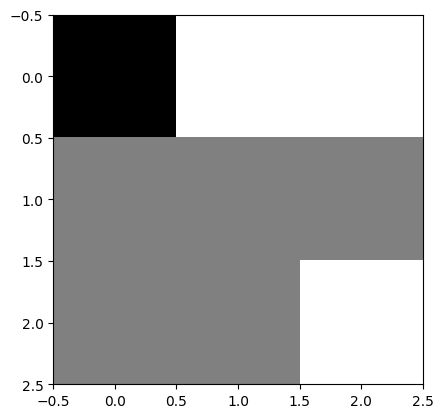

toy_image: [[0 2 2]
 [1 1 1]
 [1 1 2]]


In [4]:
toy_image = np.array([[0,2,2],[1,1,1],[1,1,2]], dtype=np.uint8)
plt.imshow(toy_image, cmap="gray")
plt.show()
print("toy_image:",toy_image)

We can use the <code>caclHist</code> function, in this case, we use only three bins as there are only three values, and the index of the bins are from 1 to 3.


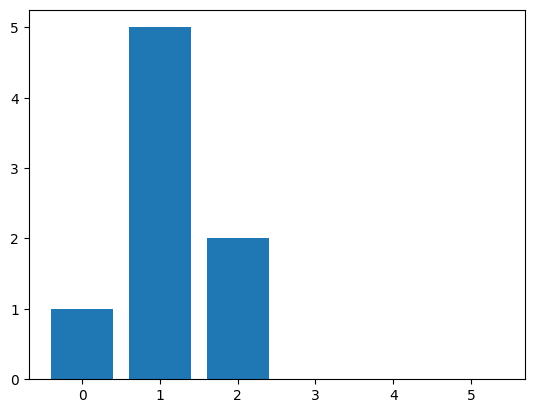

In [5]:
plt.bar([x for x in range(6)],[1,5,2,0,0,0])
plt.show()

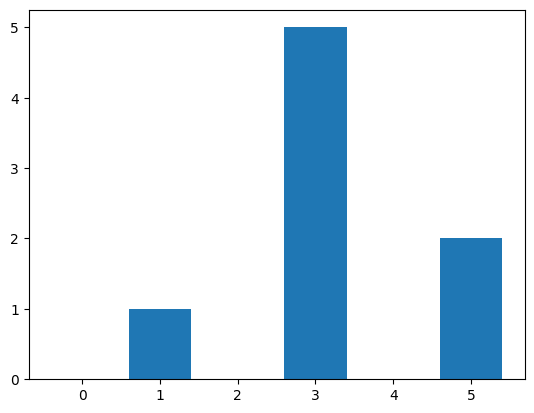

In [6]:
plt.bar([x for x in range(6)],[0,1,0,5,0,2])
plt.show()

The histogram is a function where $h[r]$  where   $r \in {0,1,2} $. In the above example  $h[0]=1$,$h[1]=5$ and $h[2]=3$


## Gray Scale Histograms


Histograms are used in grayscale images.  Grayscale images are used in many applications, including medical and industrial. Color images are split into luminance and chrominance. The luminance is the grayscale portion and is usually processed in many applications. Consider the following "Gold Hill" image:


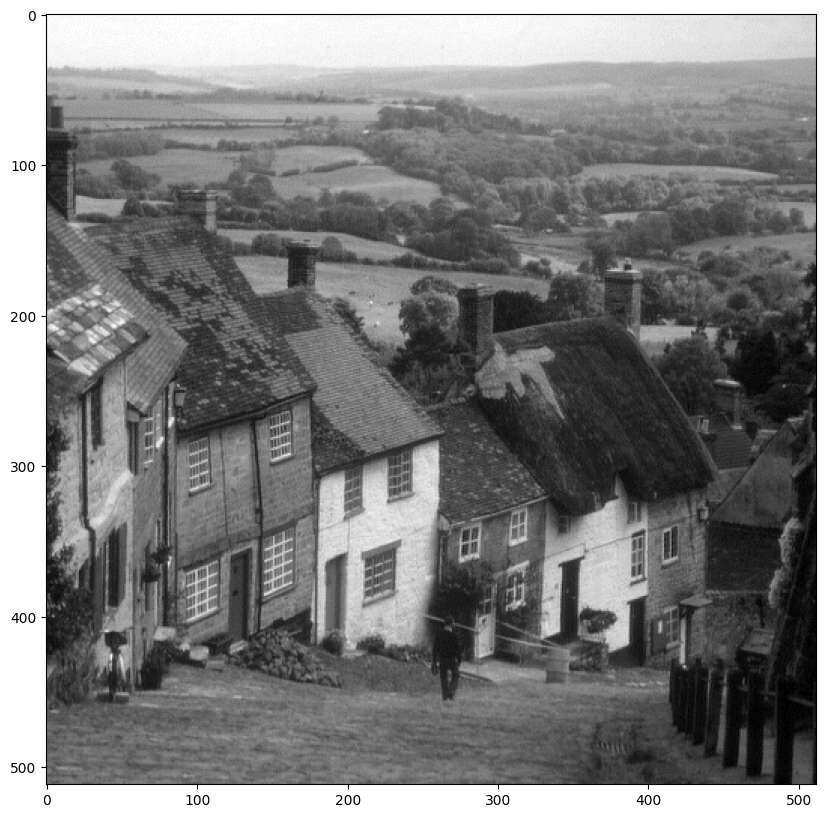

In [7]:
my_image = "goldhill.bmp"
path = 'images'
image_path = os.path.join(path, my_image)
#load an image as an array and create opencv object
goldhill = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(10,10))
plt.imshow(goldhill,cmap="gray")
plt.show()

We can calculate the histogram using the `calcHist` function from the `cv2` module as follows, the shape is 256.


In [8]:
#calculate the histogram
hist = cv2.calcHist([goldhill],[0], None, [256], [0,256])

In [9]:
hist.shape

(256, 1)

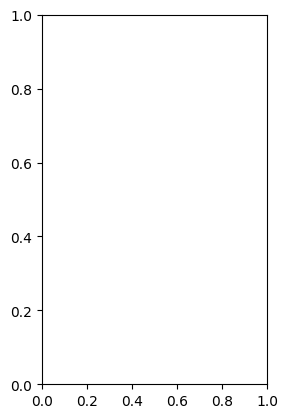

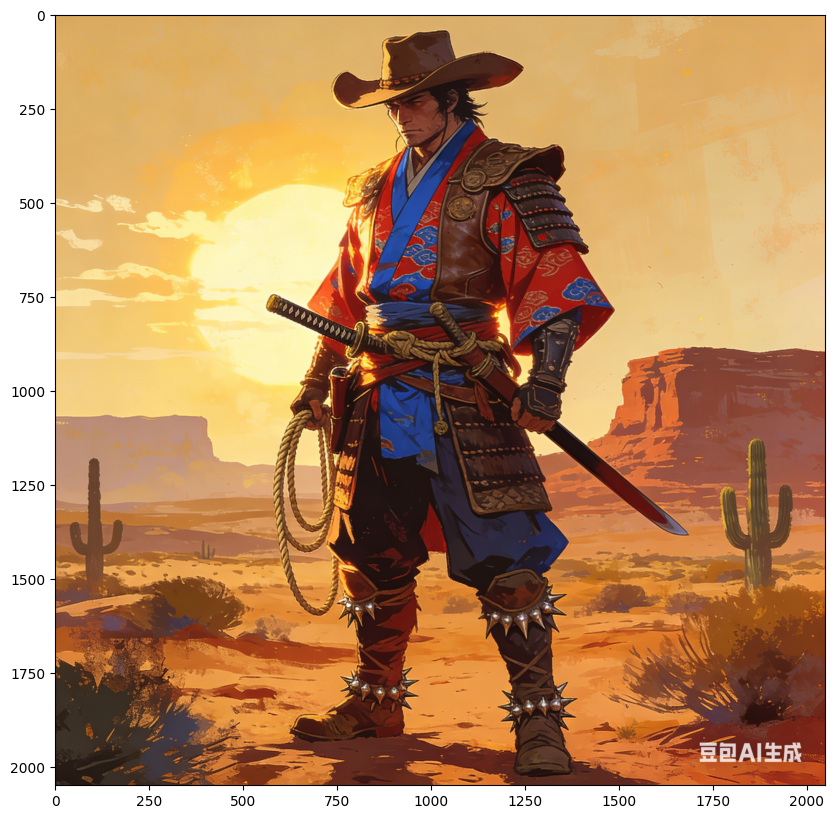

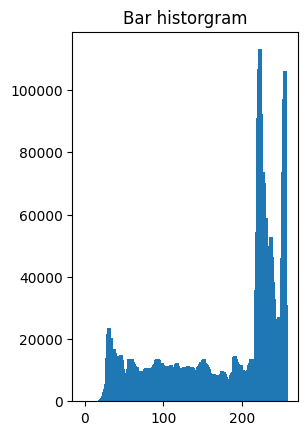

In [10]:
pic = "2.png"
pic_path = "images"
route = os.path.join(pic_path, pic)
original_image = cv2.imread(route)
rgb_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.figure(figsize=(10,10))
plt.imshow(rgb_image)
plt.show()

hist = cv2.calcHist([rgb_image],[0],None,[256],[0,256])
hist.shape
intensity = np.array([x for x in range(hist.shape[0])])
plt.subplot(1,2,2)
plt.bar(intensity, hist[:,0], width = 5)
plt.title("Bar historgram")
plt.show()


We can plot it as a bar graph, the $x$-axis are the pixel intensities and the $y$-axis is the number of times of occurrences that the corresponding pixel intensity value on $x$-axis occurred.


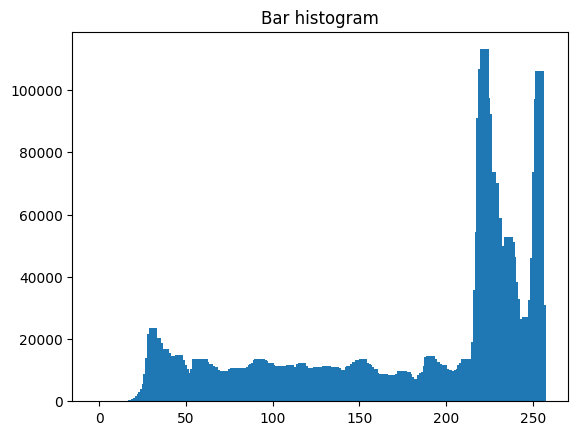

In [11]:
#plot the histogram
intensity_values = np.array([x for x in range(hist.shape[0])])
plt.bar(intensity_values, hist[:,0], width = 5)
plt.title("Bar histogram")
plt.show()

The histogram is a function where $h[r]$  where   $r \in {0,1,..,255} $.


We can convert it to a probability mass function by normalizing it by the number of pixels:


In [12]:
PMF = hist / (goldhill.shape[0] * goldhill.shape[1])

We can plot as a continuous function:


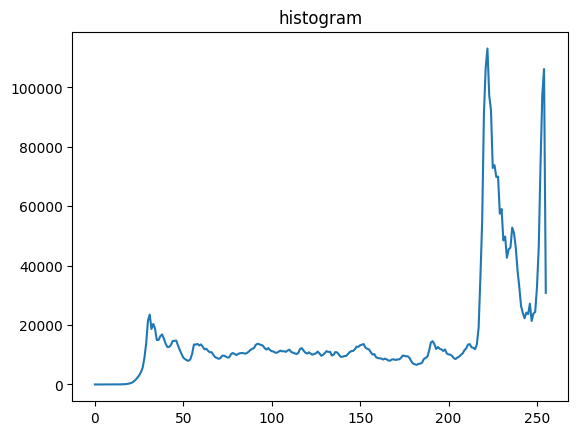

In [13]:
plt.plot(intensity_values,hist)
plt.title("histogram")
plt.show()

We can also apply a histogram to each image color channel:


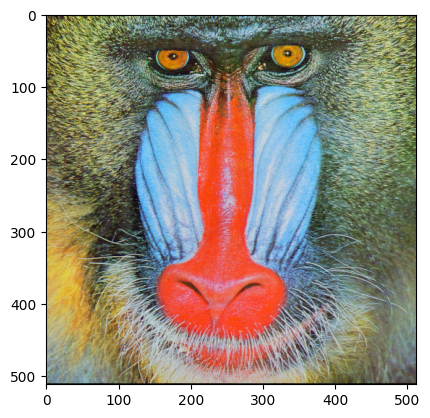

In [14]:
my_image = "baboon.png"
path = 'images'
image_path = os.path.join(path, my_image)
#load an image as an array and create opencv object
baboon = cv2.imread(image_path)
plt.imshow(cv2.cvtColor(baboon,cv2.COLOR_BGR2RGB))
plt.show()

In the loop, the value for <code>i</code> specifies what color channel <code>calcHist</code> is going to calculate the histogram for.


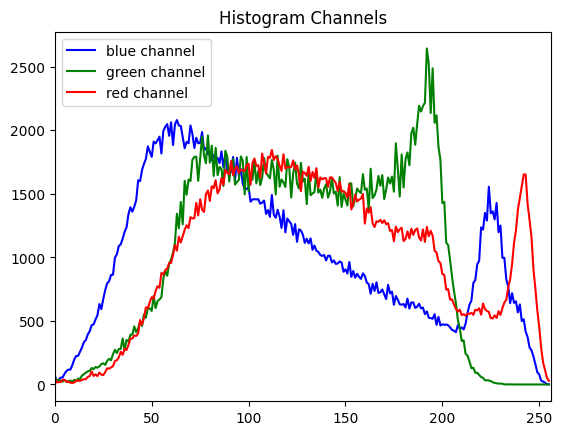

In [15]:
color = ('blue','green','red')
for i,col in enumerate(color):
    histr = cv2.calcHist([baboon],[i],None,[256],[0,256])
    plt.plot(intensity_values, histr, color = col, label = col+" channel")
    plt.xlim([0,256])
plt.legend()
plt.title("Histogram Channels")
plt.show()

# Intensity Transformations


It's helpful to think of an image as a function $f(x,y)$ instead of an array at this point, where `x` is the row index and `y` is the column index. You can apply a transformation $T$ to the image and get a new image:
$$
g(x,y)=T(f(x,y))
$$

An Intensity Transformation depends on only one single point $(x,y)$. For example, you can apply a linear transform $g(x,y) = 2f(x,y) + 1$; this will multiply each image pixel by two and add one.

As the Intensity transforms only depend on one value; as a result, it is sometimes referred to as a gray-level mapping. The variable if $r$ is the gray level intensity, similar to the histogram values. The new output s is given by:

$$
s=T(r)
$$


## Image Negatives


Consider an image with $L$ intensity values ranging from $[0,L-1]$.  We can reverse the intensity levels by applying the following:
$$
g(x,y)=L-1-f(x,y)
$$

Using the intensity transformation function notation
$$
s = L - 1 - r
$$

This is called the image negative. For $L= 256$ the formulas simplifys to:
$$
g(x,y)=255-f(x,y) \qquad and \qquad s=255-r
$$


We can perform intensity transformation on the toy image where $L = 3$:


In [25]:
#neg_toy_image = 1 * toy_image + 255
img_neg = (255 - image2.astype(np.float32)).clip(0, 255).astype(np.uint8)

print("toy image\n", toy_image)
print("image negatives\n", neg_toy_image)

toy image
 [[0 2 2]
 [1 1 1]
 [1 1 2]]
image negatives
 [[255   1   1]
 [  0   0   0]
 [  0   0   1]]


We see darker intensity’s become brighter and brighter become darker, middle intensity’s remain the same.


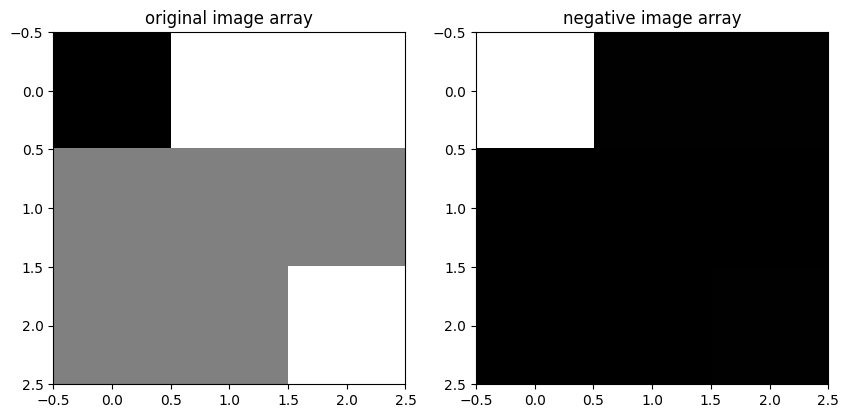

In [26]:
plt.figure(figsize=(10,10))
plt.subplot(1, 2, 1) 
plt.imshow(toy_image,cmap="gray")
plt.title("original image array")
plt.subplot(1, 2, 2)
plt.imshow(neg_toy_image,cmap="gray")
plt.title("negative image array")
plt.show()

Reversing image intensity has many applications, including making it simpler to analyze medical images. Consider the mammogram with micro-calcifications on the upper quadrant:


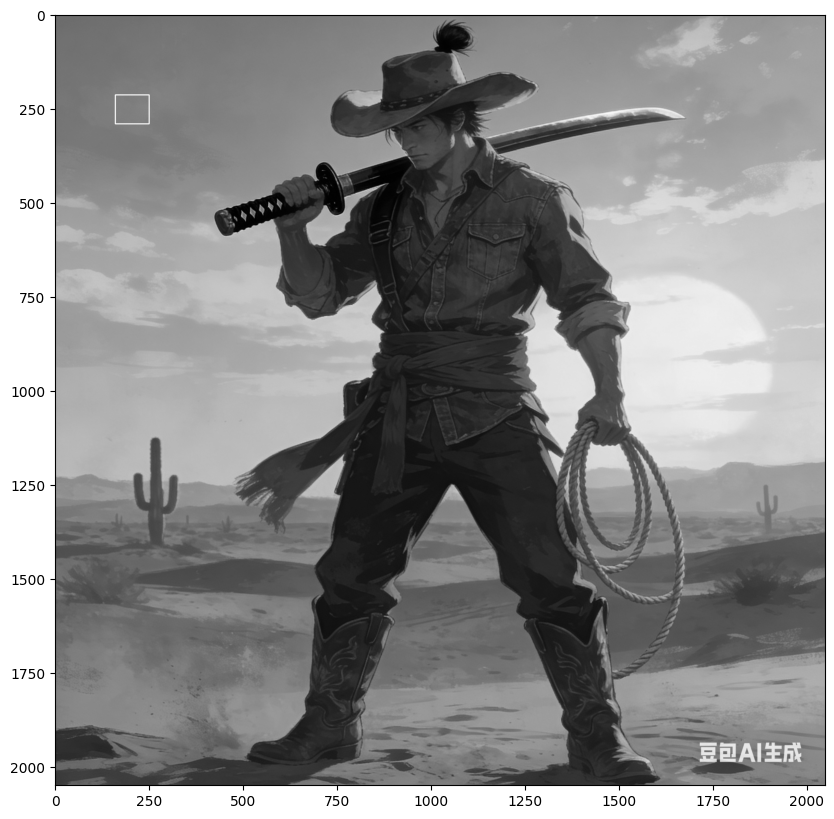

In [28]:
my_image = "1.png"
path = 'images'
image_path = os.path.join(path, my_image)
#load an image as an array and create opencv object
image2 = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
#draw rectangle
cv2.rectangle(image2, pt1=(160, 212), pt2=(250, 289), color = (255), thickness=2) 
plt.figure(figsize = (10,10))
plt.imshow(image2, cmap="gray")
plt.show()

We can apply the intensity transformation:


In [23]:
img_neg = (255 - image2.astype(np.float32)).clip(0, 255).astype(np.uint8)

We see the micro-calcifications in the image negatives is easier it is to analyze:


In [ ]:
plt.figure(figsize=(10,10))
plt.imshow(img_neg, cmap = "gray")
plt.show()

## Brightness and contrast adjustments


We can use multiplication by $\alpha$ for contrast control and addition by $\beta$ to improve brightness control. This applies the Intensity Transformation as well. The image is $f(x,y)$ and the transformed image is $g(x,y)$, where $g(x,y) = \alpha f(x,y) + \beta$.


Rather than implementing via array operations, we use the function  <code>convertScaleAbs</code>. It scales, calculates absolute values, and converts the result to 8-bit so the values fall between $[0,255]$. For brightness control, we can set $\alpha$ to 1 and $\beta$ to 100: Remember the Good Hill image, it’s dark and hazy so let's see if we can improve it.


In [ ]:
alpha = 1 # Simple contrast control
beta = 100   # Simple brightness control   
new_image = cv2.convertScaleAbs(goldhill, alpha=alpha, beta=beta)

We can plot the brighter image, it's much brighter :


In [ ]:
plot_image(goldhill, new_image, title_1 = "Orignal", title_2 = "brightness control")

We see the brighter image's histogram is shifted:


In [ ]:
plt.figure(figsize=(10,5))
plot_hist(goldhill, new_image, "Orignal", "brightness control")

We can increase the contrast by increasing $\alpha$:


In [ ]:
plt.figure(figsize=(10,5))
alpha = 2# Simple contrast control
beta = 0 # Simple brightness control   # Simple brightness control
new_image = cv2.convertScaleAbs(goldhill, alpha=alpha, beta=beta)

We can plot the image and its corresponding histogram:


In [ ]:
plot_image(goldhill,new_image,"Orignal","contrast control")

In [ ]:
plt.figure(figsize=(10,5))
plot_hist(goldhill, new_image,"Orignal","contrast control")

When plotting the image we see it's too bright. We can adapt the brightness by making the image darker and increasing the contrast at the same time.


In [ ]:
plt.figure(figsize=(10,5))
alpha = 3 # Simple contrast control
beta = -200  # Simple brightness control   
new_image = cv2.convertScaleAbs(goldhill, alpha=alpha, beta=beta)

In [ ]:
plot_image(goldhill, new_image, "Orignal", "brightness & contrast control")

In [ ]:
plt.figure(figsize=(10,5))
plot_hist(goldhill, new_image, "Orignal", "brightness & contrast control")

There are other nonlinear methods to improve contrast and brightness, these methods have different sets of parameters. In general, it’s difficult to manually adjust the contrast and brightness parameter, but there are algorithms that improve contrast automatically.


## Histogram Equalization


Histogram Equalization increases the contrast of images, by stretching out the range of the grayscale pixels; It does this by flatting  the histogram. We simply apply the function <code>cv2.equalizeHist</code>.


In [32]:
my_image = "zelda.png"
path = 'images'
image_path = os.path.join(path, my_image)
#load an image as an array and create opencv object
zelda = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
new_image = cv2.equalizeHist(zelda)

We can compare the image before and after Histogram Equalization, we see the contrast is improved. We see after the Histogram Equalization is applied, the histogram is stretched out:


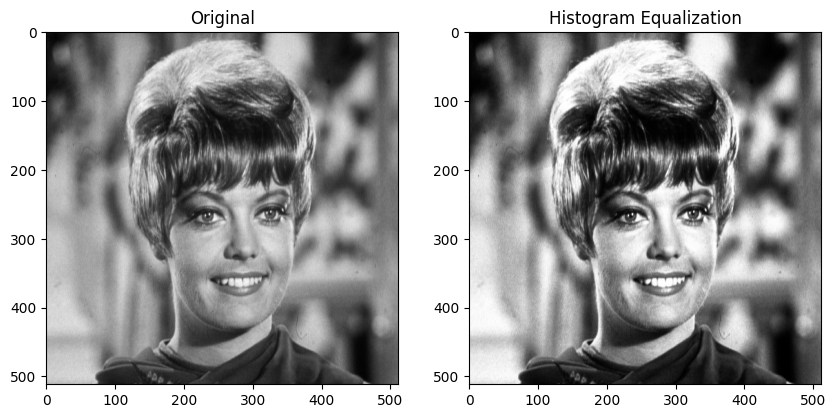

In [33]:
plot_image(zelda,new_image,"Original","Histogram Equalization")

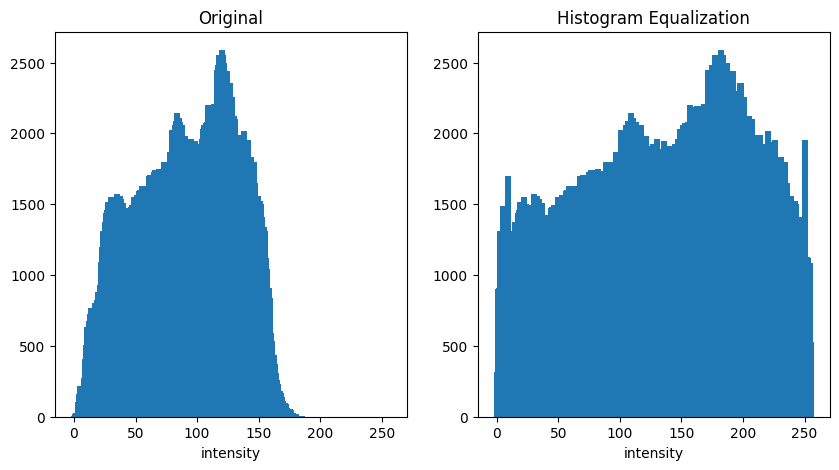

In [34]:
plt.figure(figsize=(10,5))
plot_hist(zelda, new_image,"Original","Histogram Equalization")

## Threshold Function Parameters


`src`: The image to use
`thresh`: The threshold
`maxval`: The maxval to use
`type`: Type of filtering

The threshold function works by looking at each pixel's grayscale value and assigning a value if it is below the threshold and another value if it is above the threshold. In our example the threshold is 0 (black) and the type is binary inverse so if a value is above the threshold the assigned value is 0 (black) and if it is below or equals the threshold the maxval 255 (white) is used. So if the pixel is 0 black it is assigned 255 (white) and if the pixel is not black then it is assigned black which is what THRESH_BINARY_INV tells OpenCV to do. This is how it would work without THRESH_OTSU.

Since we are using THRESH_OTSU it means that OpenCV will decide an optimal threshold. In our example below the threshold, we provide does not get used in the filter OpenCV will use an optimal one.



Consider the cameraman image:


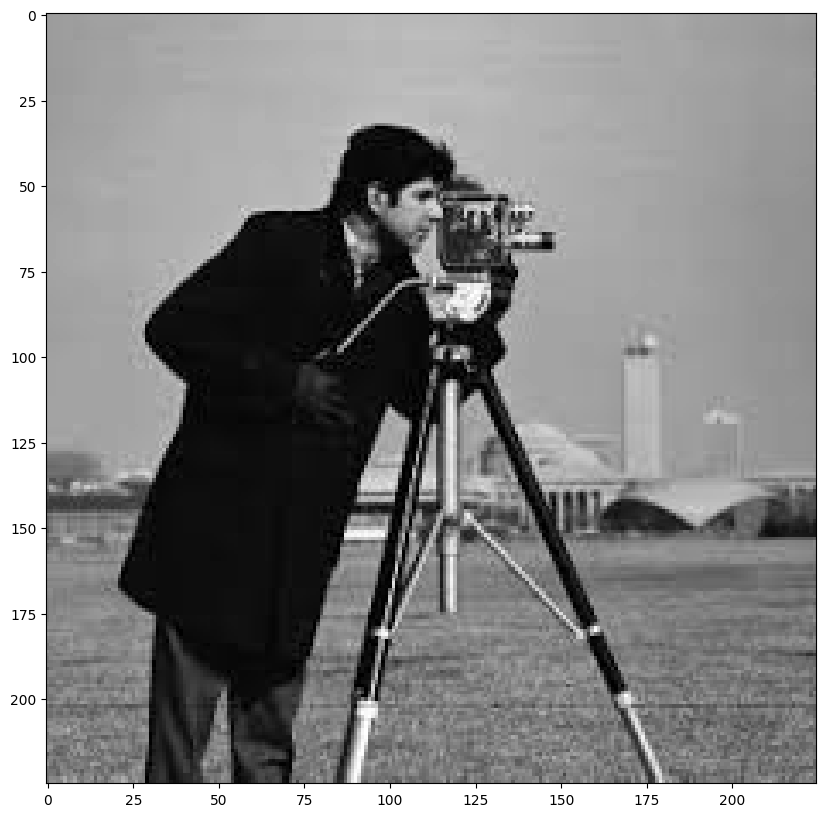

In [30]:
my_image = "cameraman.jpeg"
path = 'images'
image_path = os.path.join(path, my_image)
#load an image as an array and create opencv object
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
plt.figure(figsize=(10, 10))
plt.imshow(image, cmap="gray")
plt.show()

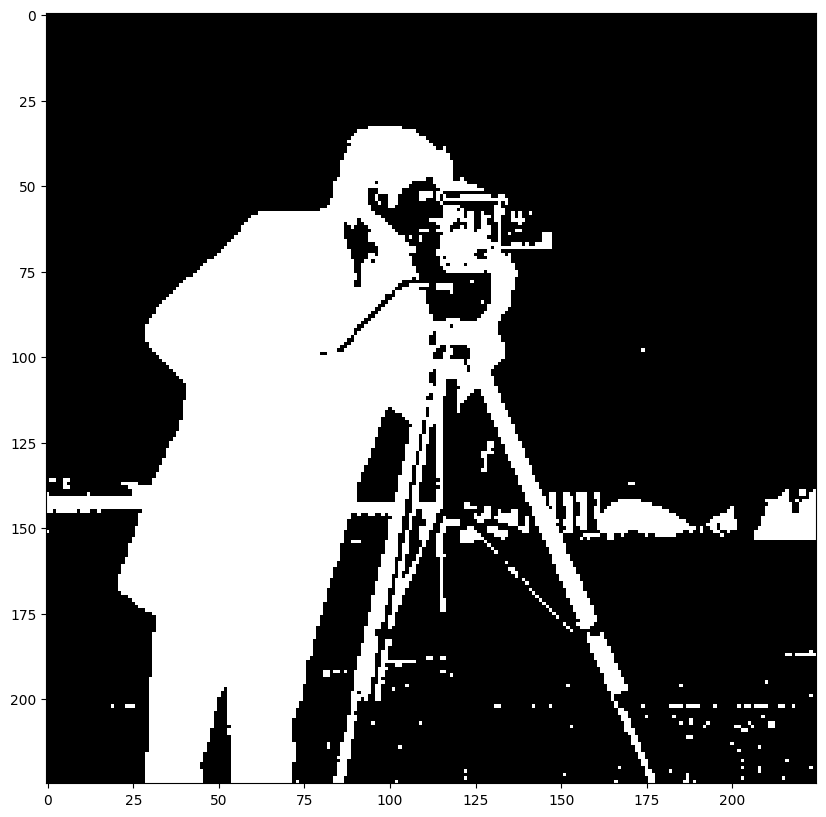

In [31]:
# Returns ret which is the threshold used and outs which is the image
ret, outs = cv2.threshold(src = image, thresh = 0, maxval = 255, type = cv2.THRESH_OTSU+cv2.THRESH_BINARY_INV)

# Make the image larger when it renders
plt.figure(figsize=(10,10))

# Render the image
plt.imshow(outs, cmap='gray')

### Question 1: Image Histogram Analysis and Operations

Choose a color image `figure2.jpg`，and read it using OpenCV

In [ ]:
# write your script here
pic = "figure1.jpg"
pic_path = "images"
route = os.path.join(pic_path, pic)
original_image = cv2.imread(route)
rgb_image = cv2.cvtColor(original_image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10,10))
plt.imshow(rgb_image)
plt.show()


In [ ]:
image_grey = cv2.cvtColor(rgb_image, cv2.COLOR_RGB2GRAY)

plt.figure(figsize=(5,5))
plt.imshow(image_grey)
plt.show()

Compute and display the histograms for the red, green, and blue channels of the image.

In [ ]:
# write your script here
color = ('blue','green','red')
for i,col in enumerate(color):
    histr = cv2.calcHist([rgb_image],[i],None,[256],[0,256])
    plt.plot(intensity, histr, color = col, label = col+" channel")
    plt.xlim([0,256])
plt.legend()
plt.title("Histogram Channels")
plt.show()

Compute and display the histogram for the entire color image

In [ ]:
# write your script here
hist = cv2.calcHist([rgb_image],[0],None,[256],[0,256])
hist.shape
intensity = np.array([x for x in range(hist.shape[0])])
plt.bar(intensity, hist[:,0], width = 5)
plt.title("Bar historgram")
plt.show()

Perform histogram equalization on the image using the function and display the beforeand-
after effect on both the image and its histogram

In [ ]:
# write your script here
eq_image = cv2.equalizeHist(image_grey)
eq_hist = cv2.calcHist([eq_image], [0], None, [256], [0,256])
eq_hist.shape
eq_intensity = np.array([x for x in range(eq_hist.shape[0])])

plt.subplot(2,2,0)
plt.figure(figsize=(10,10))
plt.imshow(eq_image)
plt.show()

plt.subplot(2,2,1)
plt.bar(eq_intensity, eq_hist[:,0], width = 5)
plt.title("Equalized histogram")
plt.show()

plt.subplot(2,2,2)
plt.bar(intensity, hist[:,0], width = 5)
plt.title("Bar historgram")
plt.show()
